# **CNN 1-DIMENSIONAL (MODELO BASE PARA EL DNSL)**

### **IMPORTACIÓN DE LIBRERÍAS**

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

# PREPROCESAMIENTO:
# ======================================================================================
from sklearn.ensemble import RandomForestRegressor

# SPLIT:
# ======================================================================================
from sklearn.model_selection import train_test_split

# RED NEURONAL:
# ======================================================================================
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
import copy
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# EVALUACIÓN:
# ======================================================================================
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import precision_recall_fscore_support

# REPRODUCIBILIDAD:
# ======================================================================================
import random

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed_everything()

### **PIPELINE DE PREPROCESAMIENTO**

In [14]:
# 0. IMPORTACIÓN DEL DATASET RAW
# ------------------------------------------------------------------------------
df_raw = pd.read_csv("../../data/raw/hydraulic_raw.csv")
print("📥 1. Datos crudos importados.")

📥 1. Datos crudos importados.


In [15]:
# 1. CONVERSIÓN TEMPORAL Y CORRECCIÓN DE ETIQUETAS
# ------------------------------------------------------------------------------
df_raw = df_raw.reset_index(drop=True)
df_raw['Time_Segundos'] = df_raw['Time'].round(1)

# Corrección de etiquetas:
def map_cooler(val): return 0 if val == 100 else (1 if val == 20 else 2)
def map_valve(val): return 0 if val == 100 else (1 if val >= 80 else 2)
def map_pump(val): return 0 if val == 0 else (1 if val == 1 else 2)
def map_acc(val): return 0 if val == 130 else (1 if val >= 100 else 2)

df_raw['Target_Fouling'] = df_raw['Cooler_Condition'].apply(map_cooler)
df_raw['Target_Valvula'] = df_raw['Valve_Condition'].apply(map_valve)
df_raw['Target_Bomba'] = df_raw['Pump_Leakage'].apply(map_pump)
df_raw['Target_Acumulador'] = df_raw['Hydraulic_Accumulator'].apply(map_acc)

# Declaramos targets y predictores:
cols_targets = ['Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador']
cols_sensores = ['PS1', 'PS3', 'EPS1', 'FS1', 'TS1', 'TS2', 'VS1']

In [16]:
# 2. RESAMPLEO A 10Hz
# ------------------------------------------------------------------------------
print("🔄 2. Resampleando a 10Hz...")
df_grouped = df_raw.groupby(['Cycle_ID', 'Time_Segundos'])[cols_sensores].mean().reset_index()
df_targs = df_raw.groupby(['Cycle_ID'])[cols_targets].first().reset_index()   
df_10hz = pd.merge(df_grouped, df_targs, on='Cycle_ID')

🔄 2. Resampleando a 10Hz...


In [17]:
# 3. SPLIT TEMPRANO (Para aislar estadísticas sin Data Leakage)
# ------------------------------------------------------------------------------
unique_cycles = df_10hz['Cycle_ID'].unique()
train_cycles, temp_cycles = train_test_split(unique_cycles, test_size=0.30, random_state=42, shuffle=True)
val_cycles, test_cycles = train_test_split(temp_cycles, test_size=0.50, random_state=42, shuffle=True)

mask_train = df_10hz['Cycle_ID'].isin(train_cycles)
TS1_MEAN_TRAIN = df_10hz.loc[mask_train, 'TS1'].mean()
TS1_STD_TRAIN = df_10hz.loc[mask_train, 'TS1'].std()
print(f"🔪 3. Split realizado. Train: {len(train_cycles)} | Val: {len(val_cycles)} | Test: {len(test_cycles)}")

🔪 3. Split realizado. Train: 1543 | Val: 331 | Test: 331


In [18]:
# ==============================================================================
# 4. GESTIÓN DE LAS TEMPERATURAS:
# ==============================================================================
# En el dataset original las temperaturas distaban de 4ºC. Realizamos una traslacion para que disten de 65ºC (más parecido a un pasteurizador real):
print("🔥 4. Desplazando temperaturas a la línea base de 65 ºC...")
df_thermo = df_10hz.copy()

# Calculamos la diferencia entre la media original del dataset y el nuevo objetivo (65 ºC)
offset_temperatura = 65.0 - TS1_MEAN_TRAIN

# Aplicamos el desplazamiento a los sensores de temperatura
df_thermo['TS1'] = df_thermo['TS1'] + offset_temperatura
df_thermo['TS2'] = df_thermo['TS2'] + offset_temperatura

🔥 4. Desplazando temperaturas a la línea base de 65 ºC...


In [19]:
# 5. DATA AUGMENTATION (Ruido solo a los sensores de Train)
# ------------------------------------------------------------------------------
print("🧬 5. Aplicando Data Augmentation en memoria (Solo a Train)...")
df_train_only = df_thermo[df_thermo['Cycle_ID'].isin(train_cycles)].copy()
df_noisy = df_train_only.copy()
df_noisy['Cycle_ID'] = df_noisy['Cycle_ID'] + 50000 

noise_level = 0.40
for c_name in cols_sensores:
    std_dev = df_noisy[c_name].std()
    noise = np.random.normal(0, std_dev * noise_level, size=len(df_noisy))
    df_noisy[c_name] += noise

df_aug = pd.concat([df_thermo, df_noisy], ignore_index=True)
train_cycles_aug = np.concatenate([train_cycles, df_noisy['Cycle_ID'].unique()])

🧬 5. Aplicando Data Augmentation en memoria (Solo a Train)...


In [20]:
# 6. FEATURE ENGINEERING (Medias y Lags para TODOS los ciclos combinados)
# ------------------------------------------------------------------------------
print("🛠️ 6. Calculando características temporales (_rmean, _rstd, _lag)...")
def engineer_features(group):
    group = group.sort_values('Time_Segundos') 
    X = group[cols_sensores]                    
    rmean = X.rolling(5, min_periods=1).mean().add_suffix('_rmean')
    rstd = X.rolling(5, min_periods=1).std().fillna(0).add_suffix('_rstd')
    lag = X.shift(1).bfill().add_suffix('_lag1') 
    return pd.concat([group, rmean, rstd, lag], axis=1)

df_final = df_aug.groupby('Cycle_ID', group_keys=False).apply(engineer_features).reset_index(drop=True)

# Reordenamos columnas:
cols_nuevas = [c for c in df_final.columns if '_rmean' in c or '_rstd' in c or '_lag1' in c]
cols_ordenadas = ['Cycle_ID', 'Time_Segundos'] + cols_sensores + cols_nuevas + cols_targets
df_final = df_final[cols_ordenadas]

display(df_final.head())

🛠️ 6. Calculando características temporales (_rmean, _rstd, _lag)...


,Cycle_ID,Time_Segundos,PS1,PS3,EPS1,FS1,TS1,TS2,VS1,PS1_rmean,...,PS3_lag1,EPS1_lag1,FS1_lag1,TS1_lag1,TS2_lag1,VS1_lag1,Target_Fouling,Target_Valvula,Target_Bomba,Target_Acumulador
0,0,0.0,151.200000,2.622500,2411.600000,8.990000,55.258927,60.649927,0.604,151.200000,...,2.622500,2411.600000,8.990000,55.258927,60.649927,0.604,2,0,0,0
1,0,0.1,154.848889,0.357667,2409.733333,4.423333,55.258927,60.649927,0.604,153.024444,...,2.622500,2411.600000,8.990000,55.258927,60.649927,0.604,2,0,0,0
2,0,0.2,160.553636,0.000000,2407.836364,0.699636,55.258927,60.649927,0.604,155.534175,...,0.357667,2409.733333,4.423333,55.258927,60.649927,0.604,2,0,0,0
3,0,0.3,167.125556,0.000000,2442.355556,0.288222,55.258927,60.649927,0.604,158.432020,...,0.000000,2407.836364,0.699636,55.258927,60.649927,0.604,2,0,0,0
4,0,0.4,174.220000,0.000000,2491.109091,0.002727,55.258927,60.649927,0.604,161.589616,...,0.000000,2442.355556,0.288222,55.258927,60.649927,0.604,2,0,0,0


In [21]:
# 7. PREPARACIÓN PYTORCH (Tensores)
# ------------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_cols = [c for c in df_final.columns if c not in ['Cycle_ID', 'Time_Segundos', 'date'] + cols_targets]

print("⚖️ 7. Escalando variables (Fit solo en Train)...")
scaler = StandardScaler()
mask_train_aug = df_final['Cycle_ID'].isin(train_cycles_aug)
scaler.fit(df_final.loc[mask_train_aug, feature_cols])

df_final[feature_cols] = scaler.transform(df_final[feature_cols])

def create_tensors(df_in, cycle_ids):
    df_subset = df_in[df_in['Cycle_ID'].isin(cycle_ids)]
    target_subset = df_subset.groupby('Cycle_ID')[cols_targets].first()
    
    x_list, y_list = [], []
    for cid in df_subset['Cycle_ID'].unique():
        cycle_data = df_subset[df_subset['Cycle_ID'] == cid][feature_cols].values
        if len(cycle_data) > 600: cycle_data = cycle_data[:600]
        elif len(cycle_data) < 600:
            pad = np.zeros((600 - len(cycle_data), len(feature_cols)))
            cycle_data = np.vstack([cycle_data, pad])
            
        x_list.append(cycle_data)
        y_list.append(target_subset.loc[cid].values)
    
    X_t = torch.tensor(np.array(x_list), dtype=torch.float32).permute(0, 2, 1)
    y_t = torch.tensor(np.array(y_list), dtype=torch.long)
    return X_t, y_t

print("📦 8. Generando Tensores y DataLoaders...")
X_train_pt, y_train_pt = create_tensors(df_final, train_cycles_aug) # Usa los aumentados
X_val_pt, y_val_pt = create_tensors(df_final, val_cycles)           # Usa originales
X_test_pt, y_test_pt = create_tensors(df_final, test_cycles)        # Usa originales

train_loader = DataLoader(TensorDataset(X_train_pt, y_train_pt), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_pt, y_val_pt), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_pt, y_test_pt), batch_size=32, shuffle=False)

print(f"✅ ¡Pipeline Completado! Tensor Train Shape: {X_train_pt.shape}")

⚖️ 7. Escalando variables (Fit solo en Train)...
📦 8. Generando Tensores y DataLoaders...
✅ ¡Pipeline Completado! Tensor Train Shape: torch.Size([3086, 28, 600])


### **Inicialización de la CNN**

**ARQUITECTURA: Vamos a usar una CNN de 1 Dimensión.** Las convoluciones 1D son excelentes para detectar "formas" en el tiempo (picos, rampas de subida, oscilaciones) independientemente de en qué segundo ocurran. Son más rápidas y ligeras que las LSTM.

**Multi-Head**: La red tendrá un "cuerpo" común (extractor de características) y 4 cabezas separadas al final (una para cada fallo).

Para **Deep Learning**, usamos la Serie Temporal Real. Necesitamos transformar los datos a esta forma: (N_Ciclos, Pasos_Tiempo, N_Sensores).
* **N_Ciclos**: 2205
* **Pasos_Tiempo**: Vamos a bajarlo a 60 pasos (1 dato por segundo). ¿Por qué? Porque los sensores de temperatura (TS1) solo tienen 1 dato por segundo. Si usamos 6000 pasos, tendríamos que repetir el valor de temperatura 100 veces, lo cual añade ruido y peso computacional inútil. 60 pasos es suficiente para ver la curva.
* **N_Sensores**: 10 (PS1, PS2, EPS1, etc.)

In [22]:
# ==============================================================================
# DEFINICIÓN DE LA ARQUITECTURA (CNN 1D MULTI-HEAD)
# ==============================================================================
# La red tendrá un "cuerpo" común (extractor de características) y 4 cabezas 
# separadas al final (una para cada componente).

import torch.nn as nn

class CNN_Pasteurizer(nn.Module):
    def __init__(self, n_sensors, n_classes=3, dropout_prob=0.5):
        super(CNN_Pasteurizer, self).__init__()
        
        # Backbone (Extractor de características espaciotemporales)
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv1d(n_sensors, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.1),
            
            # Bloque 2
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.1),
            
            # Bloque 3
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.2),
            
            # Bloque 4 (Consolidación)
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            
            # Global Pooling: Colapsa el eje temporal a 1 único vector descriptivo
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.dropout_final = nn.Dropout(dropout_prob)
        
        # 4 Cabezas de Clasificación Independientes (One-vs-Rest interno)
        self.head_fouling = nn.Linear(256, n_classes)
        self.head_valvula = nn.Linear(256, n_classes)
        self.head_bomba = nn.Linear(256, n_classes)
        self.head_acumulador = nn.Linear(256, n_classes)

    def forward(self, x):
        # x shape: (Batch, Canales, Pasos_Temporales)
        x = self.features(x)
        x = x.squeeze(-1) # Quitar dimensión tiempo: (Batch, 256, 1) -> (Batch, 256)
        x = self.dropout_final(x)
        
        # Retorna 4 tensores de logits
        return self.head_fouling(x), self.head_valvula(x), self.head_bomba(x), self.head_acumulador(x)

print("🧠 Arquitectura CNN_Pasteurizer definida correctamente en memoria.")

🧠 Arquitectura CNN_Pasteurizer definida correctamente en memoria.


In [23]:
# ==============================================================================
# 4. ENTRENAMIENTO ESTÁNDAR (SIN RESTRICCIONES FÍSICAS)
# ==============================================================================
n_canales = len(feature_cols)

# OJO: Estos parámetros son genéricos. Idealmente pasarían por Optuna también.
learning_rate = 0.001 
dropout_rate = 0.3

model_cnn = CNN_Pasteurizer(n_sensors=n_canales, n_classes=3, dropout_prob=dropout_rate).to(device)
optimizer = optim.Adam(model_cnn.parameters(), lr=learning_rate)

# Usamos CrossEntropyLoss simple, sin ecuaciones termodinámicas ni inercias
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

EPOCHS = 150
patience = 15
best_val_loss = float('inf')
counter = 0
best_model_weights = copy.deepcopy(model_cnn.state_dict())

print(f"🚀 Iniciando entrenamiento CNN Standard...")
start_time = time.time()

for epoch in range(EPOCHS):
    
    # --- TRAIN ---
    model_cnn.train()
    run_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        p_foul, p_valv, p_bomb, p_acum = model_cnn(inputs)
        
        # Loss combinada de las 4 cabezas
        loss = criterion(p_foul, labels[:, 0]) + \
               criterion(p_valv, labels[:, 1]) + \
               criterion(p_bomb, labels[:, 2]) + \
               criterion(p_acum, labels[:, 3])
               
        loss.backward()
        optimizer.step()
        run_loss += loss.item()
        
    avg_train_loss = run_loss / len(train_loader)
    
    # --- VALIDATION ---
    model_cnn.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            p_foul, p_valv, p_bomb, p_acum = model_cnn(inputs)
            
            l1 = criterion(p_foul, labels[:, 0])
            l2 = criterion(p_valv, labels[:, 1])
            l3 = criterion(p_bomb, labels[:, 2])
            l4 = criterion(p_acum, labels[:, 3])
            val_loss += (l1+l2+l3+l4).item()
            
            # Exact Match Accuracy
            _, pred_f = torch.max(p_foul, 1)
            _, pred_v = torch.max(p_valv, 1)
            _, pred_b = torch.max(p_bomb, 1)
            _, pred_a = torch.max(p_acum, 1)
            
            rows_match = (pred_f == labels[:, 0]) & (pred_v == labels[:, 1]) & \
                         (pred_b == labels[:, 2]) & (pred_a == labels[:, 3])
            correct += rows_match.sum().item()
            total += labels.size(0)
            
    val_acc = correct / total
    avg_val_loss = val_loss / len(val_loader)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    
    # Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_weights = copy.deepcopy(model_cnn.state_dict())
        counter = 0
    else:
        counter += 1
        
    if (epoch+1) % 5 == 0:
        print(f"Ep {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: {val_acc:.4f}")
        
    if counter >= patience:
        print(f"⏹️ Early Stopping en época {epoch+1}")
        break

end_time = time.time()
mins = int((end_time - start_time) // 60)
secs = int((end_time - start_time) % 60)
print(f"✅ Entrenamiento CNN Standard finalizado en {mins}m {secs}s.")

# Cargar mejor modelo
model_cnn.load_state_dict(best_model_weights)

🚀 Iniciando entrenamiento CNN Standard...
Ep 005 | Train Loss: 1.7789 | Val Loss: 1.5099 | Acc: 0.5106
Ep 010 | Train Loss: 1.2283 | Val Loss: 0.9304 | Acc: 0.6949
Ep 015 | Train Loss: 0.7538 | Val Loss: 0.4155 | Acc: 0.9063
Ep 020 | Train Loss: 0.5971 | Val Loss: 0.3831 | Acc: 0.8852
Ep 025 | Train Loss: 0.5364 | Val Loss: 0.4902 | Acc: 0.8640
Ep 030 | Train Loss: 0.5036 | Val Loss: 0.2680 | Acc: 0.9335
Ep 035 | Train Loss: 0.4111 | Val Loss: 0.2425 | Acc: 0.9124
Ep 040 | Train Loss: 0.4082 | Val Loss: 0.1771 | Acc: 0.9577
Ep 045 | Train Loss: 0.3847 | Val Loss: 0.1439 | Acc: 0.9668
Ep 050 | Train Loss: 0.3436 | Val Loss: 0.1591 | Acc: 0.9366
Ep 055 | Train Loss: 0.3382 | Val Loss: 0.1794 | Acc: 0.9396
Ep 060 | Train Loss: 0.2976 | Val Loss: 0.2639 | Acc: 0.9094
Ep 065 | Train Loss: 0.2913 | Val Loss: 0.1915 | Acc: 0.9335
Ep 070 | Train Loss: 0.2677 | Val Loss: 0.1320 | Acc: 0.9668
Ep 075 | Train Loss: 0.2706 | Val Loss: 0.0983 | Acc: 0.9758
Ep 080 | Train Loss: 0.2474 | Val Loss: 0.1

<All keys matched successfully>

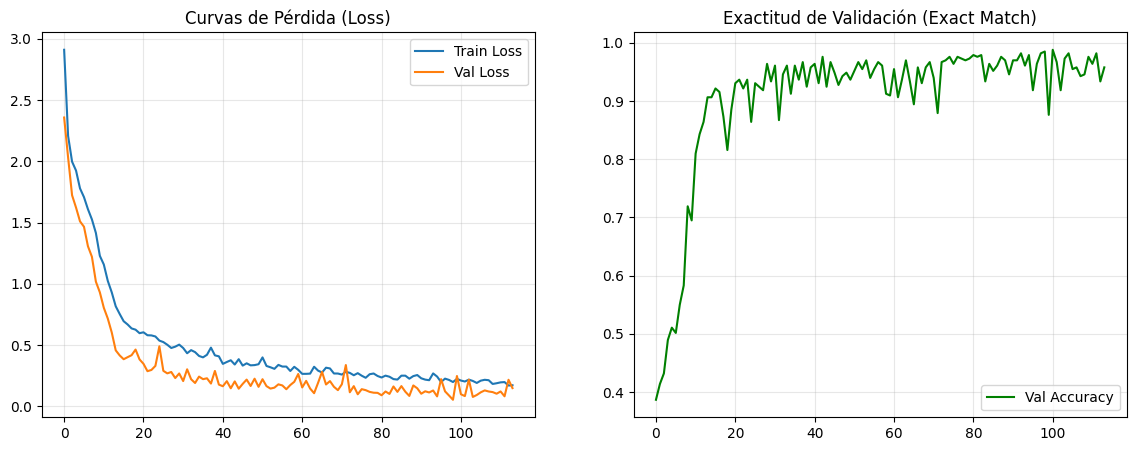

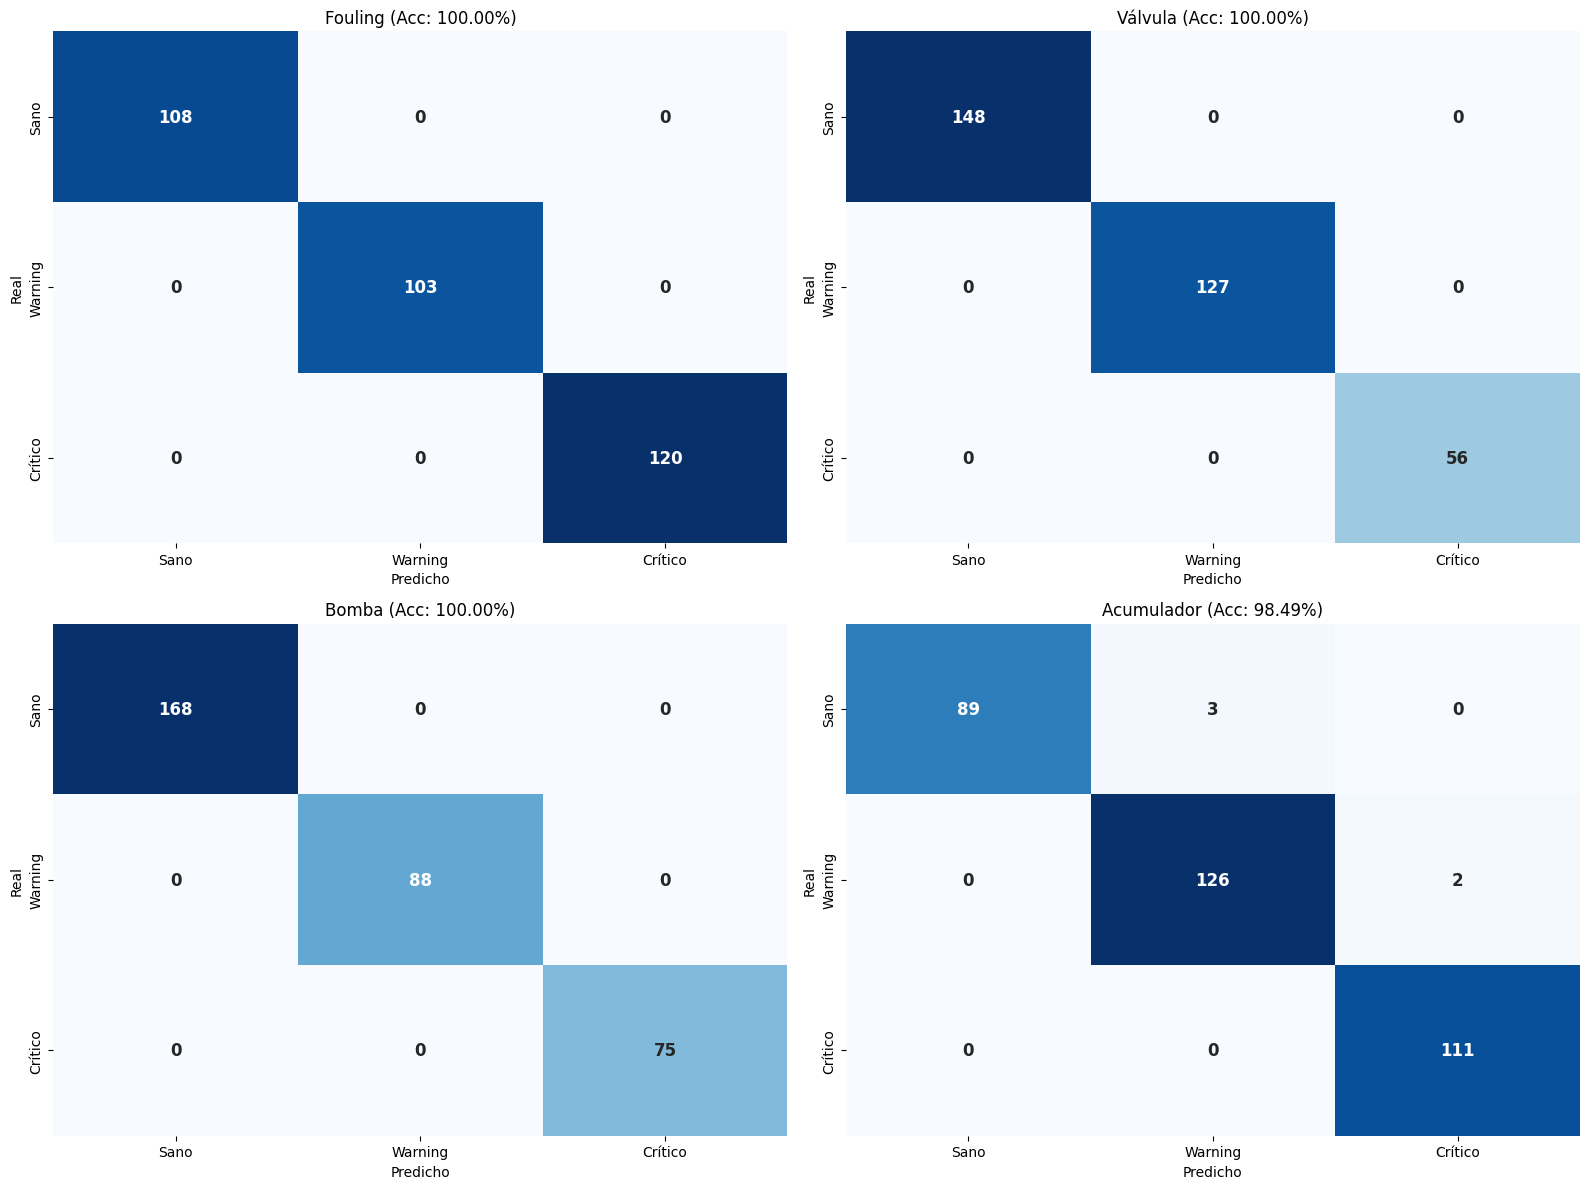


     📊 MÉTRICAS GLOBALES DEL MODELO CNN-1D STANDARD    
 🔹 Exactitud Global (Subset) :  0.9849
 🔹 Recall Global (Macro)     :  0.9960
 🔹 F1-Score Global (Macro)   :  0.9963



In [24]:
# ==============================================================================
# 5. EVALUACIÓN Y MATRICES DE CONFUSIÓN
# ==============================================================================
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Curvas de Pérdida (Loss)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='green')
plt.title('Exactitud de Validación (Exact Match)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


model_cnn.eval()
y_true_list, y_pred_list = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.cpu().numpy()
        
        p_foul, p_valv, p_bomb, p_acum = model_cnn(inputs)
        
        preds_batch = torch.stack([
            p_foul.argmax(1), p_valv.argmax(1), p_bomb.argmax(1), p_acum.argmax(1)
        ], dim=1).cpu().numpy()

        y_true_list.append(labels)
        y_pred_list.append(preds_batch)

y_true = np.vstack(y_true_list)
y_pred = np.vstack(y_pred_list)

target_names = ['Fouling', 'Válvula', 'Bomba', 'Acumulador']
class_labels = ['Sano', 'Warning', 'Crítico']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i in range(4):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])
    acc = accuracy_score(y_true[:, i], y_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False,
                annot_kws={"size": 12, "weight": "bold"})
    axes[i].set_title(f'{target_names[i]} (Acc: {acc:.2%})')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Predicho')

plt.tight_layout()
plt.show()

# ==============================================================================
# 6. MÉTRICAS GLOBALES
# ==============================================================================
subset_accuracy = (y_true == y_pred).all(axis=1).mean()
recalls_macro, f1s_macro = [], []

for i in range(4):
    recalls_macro.append(recall_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0))
    f1s_macro.append(f1_score(y_true[:, i], y_pred[:, i], average='macro', zero_division=0))

global_macro_recall = np.mean(recalls_macro)
global_macro_f1 = np.mean(f1s_macro)

print("\n" + "="*55)
print(" 📊 MÉTRICAS GLOBALES DEL MODELO CNN-1D STANDARD ".center(55))
print("="*55)
print(f" 🔹 Exactitud Global (Subset) :  {subset_accuracy:.4f}")
print(f" 🔹 Recall Global (Macro)     :  {global_macro_recall:.4f}")
print(f" 🔹 F1-Score Global (Macro)   :  {global_macro_f1:.4f}")
print("="*55 + "\n")